from google.colab import drive
drive.mount('/content/drive')

## 1. Nạp thư viện

In [ ]:
# ====================== 1. NẠP THƯ VIỆN ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


In [ ]:
# ====================== 2. LOAD DATA ======================
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/customer_shopping_data.csv')

print("=== KÍCH THƯỚC DỮ LIỆU GỐC ===")
print(f"Số dòng: {dataset.shape[0]:,} | Số cột: {dataset.shape[1]}")
display(dataset.head())


=== KÍCH THƯỚC DỮ LIỆU GỐC ===
Số dòng: 99,457 | Số cột: 10


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
# ====================== 3. KHÁM PHÁ DỮ LIỆU (EDA) ======================
print("\n=== THÔNG TIN TỔNG QUAN ===")
print(dataset.info())

print("\n=== THỐNG KÊ CƠ BẢN ===")
display(dataset.describe(include='all'))

print("\n=== MISSING VALUES ===")
display(dataset.isnull().sum())



=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None

=== THỐNG KÊ CƠ BẢN ===


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457.000000,99457,99457.000000,99457.000000,99457,99457,99457
unique,99457,99457,2,NaN,8,NaN,NaN,3,797,10
top,I232867,C273973,Female,NaN,Clothing,NaN,NaN,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,NaN,34487,NaN,NaN,44447,159,19943
mean,NaN,NaN,NaN,43.427089,NaN,3.003429,689.256321,NaN,NaN,NaN
std,NaN,NaN,NaN,14.990054,NaN,1.413025,941.184567,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,1.000000,5.230000,NaN,NaN,NaN
25%,NaN,NaN,NaN,30.000000,NaN,2.000000,45.450000,NaN,NaN,NaN
50%,NaN,NaN,NaN,43.000000,NaN,3.000000,203.300000,NaN,NaN,NaN
75%,NaN,NaN,NaN,56.000000,NaN,4.000000,1200.320000,NaN,NaN,NaN



=== MISSING VALUES ===


,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [ ]:
# Are there any duplicated rows?
dataset.duplicated().sum()

np.int64(0)

In [ ]:
# ====================== 4. TIỀN XỬ LÝ & FEATURE ENGINEERING ======================
dataset['invoice_date'] = pd.to_datetime(dataset['invoice_date'], dayfirst=True)

age_groups = [18, 24, 34, 44, 54, 64, 70]
labels = ['18-24','25-34','35-44','45-54','55-64','65-70']
dataset['age_group'] = pd.cut(dataset['age'], bins=age_groups, labels=labels)

dataset['TotalAmount'] = dataset['price'] * dataset['quantity']

dataset['Year'] = dataset['invoice_date'].dt.year
dataset['Month'] = dataset['invoice_date'].dt.month
dataset['DayOfWeek'] = dataset['invoice_date'].dt.dayofweek
dataset['IsWeekend'] = dataset['DayOfWeek'].isin([5, 6]).astype(int)

print("=== DỮ LIỆU SAU FEATURE ENGINEERING ===")
display(dataset.head())


=== DỮ LIỆU SAU FEATURE ENGINEERING ===


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,age_group,TotalAmount,Year,Month,DayOfWeek,IsWeekend
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,25-34,7502.00,2022,8,4,0
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,18-24,5401.53,2021,12,6,1
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,18-24,300.08,2021,11,1,0
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,65-70,15004.25,2021,5,6,1
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,45-54,242.40,2021,10,6,1


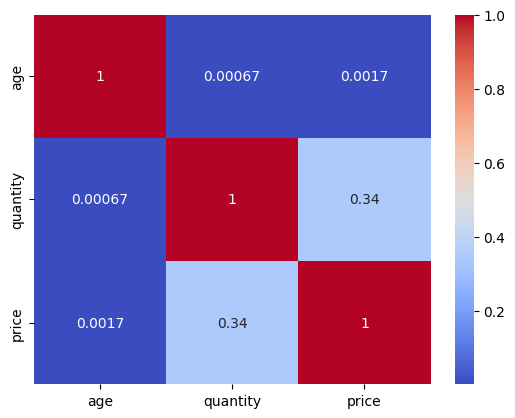

In [ ]:
# Correlation heatmap (chỉ dùng cột số)
numeric_dataset = dataset.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_dataset.corr(), annot=True, cmap='coolwarm')
plt.show()

[Text(0.5, 1.0, 'Gender and number of transactions')]

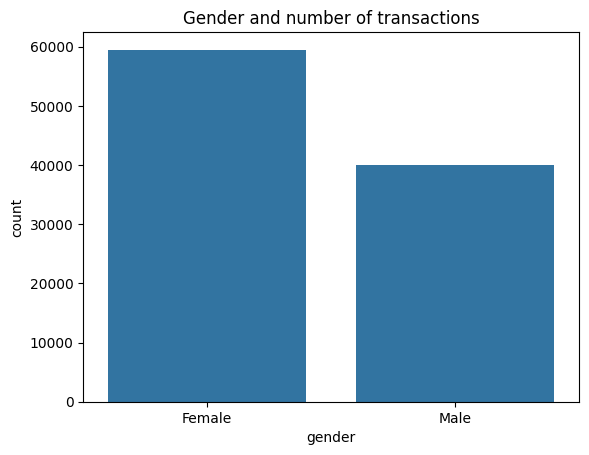

In [ ]:
#First, investigate gender columns and see if we get some insights
sns.countplot(data=dataset,x='gender').set(title='Gender and number of transactions')

[Text(0.5, 1.0, 'Age distribution and number of transactions')]

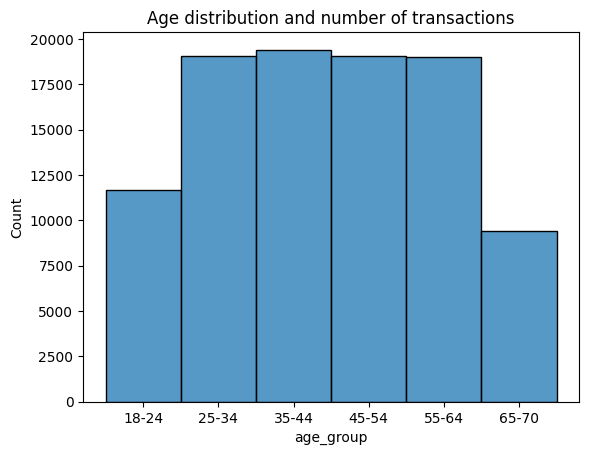

In [ ]:
# Build histogram of age distribution per number of transactions
sns.histplot(data=dataset, x='age_group').set(title = 'Age distribution and number of transactions')

[Text(0.5, 1.0, 'Age group and total spent')]

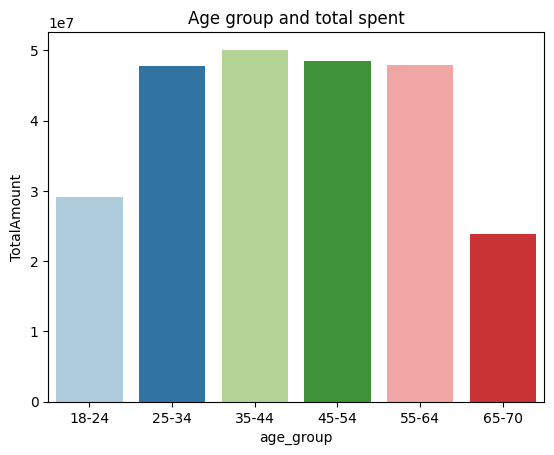

In [ ]:
# Which age group spent more money?
age_group_total = dataset.groupby('age_group')['TotalAmount'].sum().reset_index()
sns.barplot(data=age_group_total, x='age_group', y='TotalAmount', palette = 'Paired').\
set(title='Age group and total spent')

Text(0.5, 1.0, 'Age distribution for females and males customers')

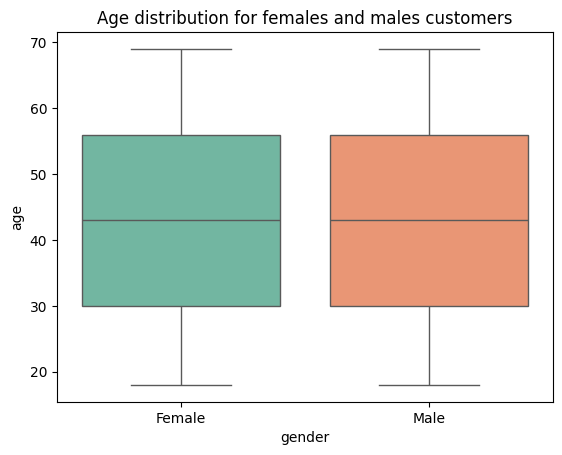

In [ ]:
# Check age distribution among males and females
sns.boxplot(data=dataset, x='gender', y='age', palette='Set2')
plt.title('Age distribution for females and males customers')

[Text(0.5, 1.0, 'Payment method and number of transactions')]

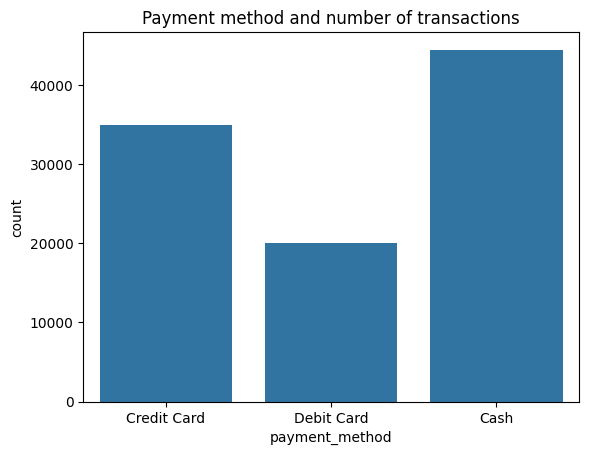

In [ ]:
# Explore payment methods
sns.countplot(x='payment_method', data=dataset).set(title='Payment method and number of transactions')

In [ ]:
# Most customers are paying by cash. But what about the amount of money spent and payment method?
dataset_payment = pd.DataFrame(dataset.groupby('payment_method')['TotalAmount'].sum())
dataset_payment

,TotalAmount
payment_method,
Cash,1.128322e+08
Credit Card,8.807712e+07
Debit Card,5.059643e+07


Text(0.5, 1.0, 'Price distribution')

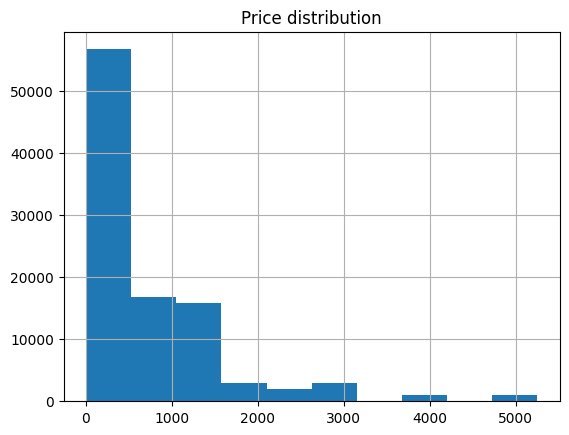

In [ ]:
# Investigate which products price customers usually prefer
dataset.price.hist()
plt.title('Price distribution')

In [ ]:
# Discover popular categories
dataset_category_count = dataset.groupby('category')['invoice_no'].count().reset_index()
dataset_category_count.sort_values(by='invoice_no', ascending=False)

,category,invoice_no
1,Clothing,34487
2,Cosmetics,15097
3,Food & Beverage,14776
7,Toys,10087
4,Shoes,10034
5,Souvenir,4999
6,Technology,4996
0,Books,4981


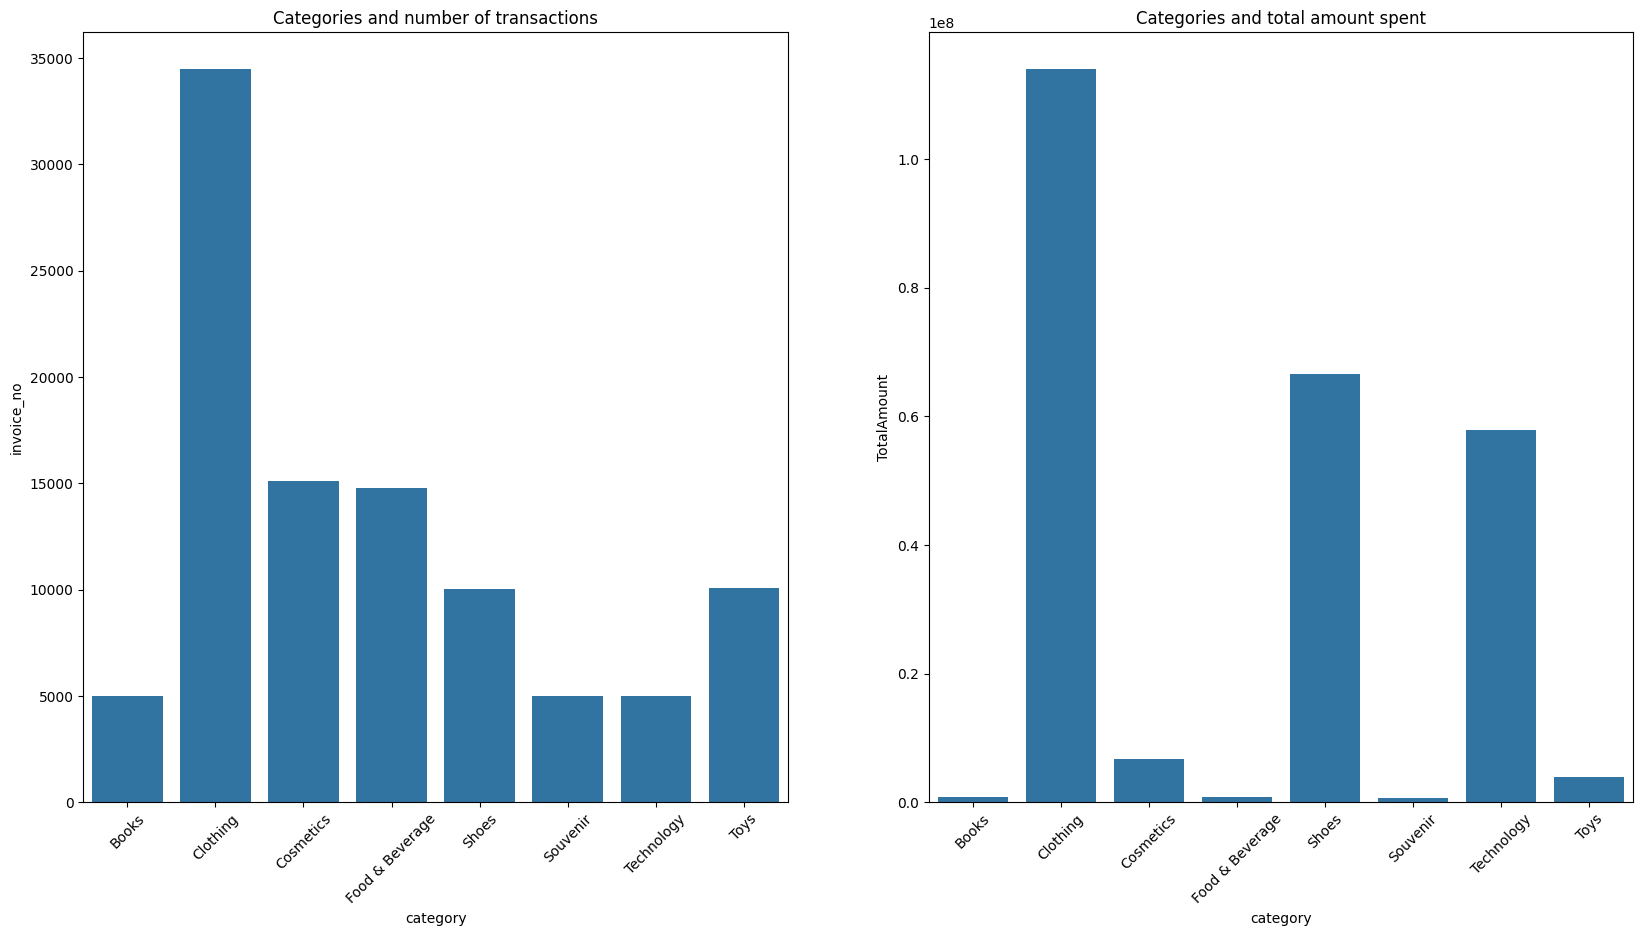

In [ ]:
# Visualize popular categories per number of transactions and total amount spent
dataset_category_total = dataset.groupby('category')['TotalAmount'].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,10))
sns.barplot(data=dataset_category_count, x='category', y='invoice_no', ax = ax1).set(title='Categories and number of transactions')
sns.barplot(data=dataset_category_total, x='category', y = 'TotalAmount', ax = ax2).set(title='Categories and total amount spent')
ax1.tick_params('x', labelrotation=45)
ax2.tick_params('x', labelrotation=45)

In [ ]:
# What is the average price per category?
avg_price_category = pd.DataFrame(dataset.groupby('category')['price'].mean().sort_values(ascending=False))
avg_price_category.columns = ['average_price']
avg_price_category

,average_price
category,
Technology,3156.935548
Shoes,1807.388568
Clothing,901.084021
Cosmetics,122.448626
Toys,107.733185
Books,45.568621
Souvenir,34.894345
Food & Beverage,15.671948


In [ ]:
# Distribution number of transaction per age groups and gender
pd.crosstab([dataset.age_group, dataset.gender], dataset.category, values=dataset.invoice_no, aggfunc=(['count']))

count                                                    \
category         Books Clothing Cosmetics Food & Beverage Shoes Souvenir   
age_group gender                                                           
18-24     Female   326     2389      1024            1042   704      340   
          Male     255     1651       688             728   492      224   
25-34     Female   553     4010      1757            1644  1113      596   
          Male     388     2595      1154            1159   811      382   
35-44     Female   578     4039      1748            1787  1153      583   
          Male     364     2710      1164            1138   752      404   
45-54     Female   544     3924      1744            1674  1191      576   
          Male     412     2678      1186            1120   775      339   
55-64     Female   562     3983      1755            1653  1153      602   
          Male     418     2621      1174            1147   779      381   
65-70     Female   277     1921       877             849   552      264   
          Male     198     1320       559             554   388      200   

                                   
category         Technology  Toys  
age_group gender                   
18-24     Female        341   693  
          Male          218   537  
25-34     Female        594  1207  
          Male          371   747  
35-44     Female        606  1199  
          Male          434   742  
45-54     Female        561  1141  
          Male          398   786  
55-64     Female        552  1127  
          Male          351   745  
65-70     Female        275   620  
          Male          206   367

In [ ]:
# How much did each combination of gender and age group spent in total in different categories?
pd.crosstab([dataset.age_group, dataset.gender], dataset.category, values=dataset.TotalAmount, aggfunc=np.sum, normalize='columns').\
applymap(lambda x: "{0:.0f}%".format(100*x))

category         Books Clothing Cosmetics Food & Beverage Shoes Souvenir  \
age_group gender                                                           
18-24     Female    7%       7%        7%              7%    7%       7%   
          Male      6%       5%        4%              5%    5%       5%   
25-34     Female   12%      12%       12%             11%   11%      13%   
          Male      8%       8%        8%              8%    8%       8%   
35-44     Female   12%      12%       12%             13%   12%      12%   
          Male      7%       8%        8%              8%    8%       8%   
45-54     Female   10%      12%       11%             11%   12%      11%   
          Male      8%       8%        8%              8%    8%       7%   
55-64     Female   11%      12%       11%             11%   12%      12%   
          Male      9%       8%        8%              8%    8%       8%   
65-70     Female    6%       6%        6%              6%    6%       5%   
          Male      4%       4%        4%              4%    4%       4%   

category         Technology Toys  
age_group gender                  
18-24     Female         7%   7%  
          Male           4%   5%  
25-34     Female        11%  12%  
          Male           7%   7%  
35-44     Female        13%  12%  
          Male           9%   7%  
45-54     Female        11%  11%  
          Male           8%   8%  
55-64     Female        12%  12%  
          Male           7%   8%  
65-70     Female         6%   6%  
          Male           4%   4%

In [ ]:
# The most popular shopping malls by number of transactions
pd.DataFrame(dataset['shopping_mall'].value_counts())

,count
shopping_mall,
Mall of Istanbul,19943
Kanyon,19823
Metrocity,15011
Metropol AVM,10161
Istinye Park,9781
Zorlu Center,5075
Cevahir AVM,4991
Forum Istanbul,4947
Viaport Outlet,4914


In [ ]:
!pip install squarify

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

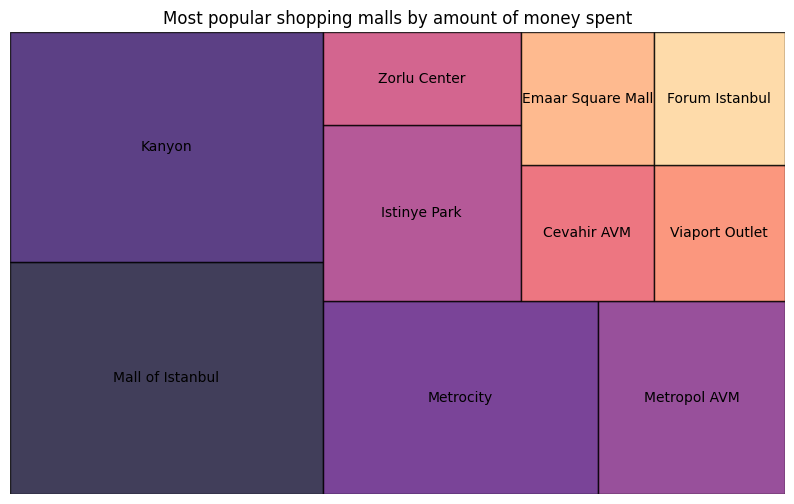

In [ ]:
import squarify

# And which shopping mall has the biggest amount of money spent? Lets visualize it
malls = dataset.groupby('shopping_mall')['TotalAmount'].sum().reset_index().sort_values(by='TotalAmount', ascending=False)
plt.figure(figsize=(10,6))
squarify.plot(sizes=malls['TotalAmount'], label=malls['shopping_mall'], alpha=.8, color=sns.color_palette("magma",
                                     len(malls)), ec='black' )
plt.title('Most popular shopping malls by amount of money spent')
plt.axis('off')

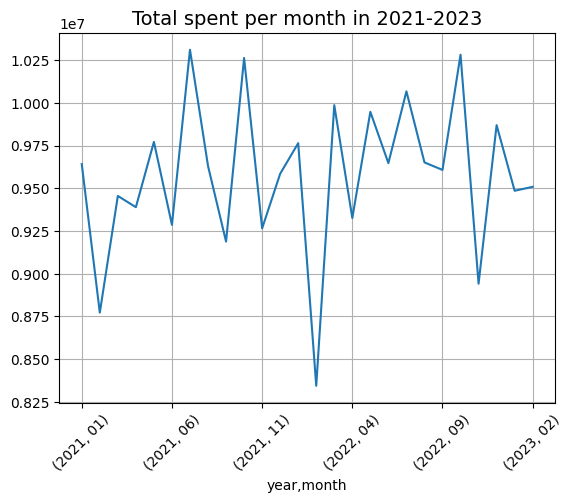

In [ ]:
# Interesting to see how the total amount of money spent changed per year
# But we will not include data from March 2023 since it is not full (only till the 8th of March available)
year_month = dataset[dataset['invoice_date'] < '2023-03-01'].groupby(['year', 'month'])['TotalAmount'].sum()
year_month.plot(grid=True)
plt.title('Total spent per month in 2021-2023', size=14)
plt.tick_params('x', labelrotation=45)

##Tóm tắt
Sau khi phân tích, chúng tôi nhận thấy phụ nữ trong độ tuổi 35-44 và 45-54 chi tiêu nhiều tiền nhất (so với các nhóm tuổi và giới tính khác) tại các trung tâm mua sắm, cũng như xét theo số lượng giao dịch (tần suất họ đến trung tâm mua sắm).

Khách hàng ưa chuộng các sản phẩm giá rẻ, trong khoảng 0-1000 TL.

Các mặt hàng phổ biến nhất xét theo số lượng giao dịch: Quần áo, Mỹ phẩm, Thực phẩm và đồ uống. Tuy nhiên, xét theo tổng chi tiêu: Quần áo, Giày dép và Công nghệ.

Các trung tâm mua sắm phổ biến nhất là Mall of Istanbul, Kanyon và Metrocity.

Doanh thu hàng tháng của các trung tâm mua sắm ở Istanbul không ổn định trong 3 năm qua, và đã giảm vào năm 2023. Vì vậy, các chủ doanh nghiệp có thể đề xuất thực hiện các chiến dịch truyền thông xã hội (hoặc bất kỳ hình thức quảng cáo nào khác) nhắm mục tiêu vào phụ nữ trong độ tuổi 35-54 thuộc các danh mục Quần áo, Giày dép và Công nghệ.

In [ ]:
# ====================== 6. CHUẨN BỊ DỮ LIỆU CHO LINEAR REGRESSION ======================
# Bỏ 'price' để tránh lộ công thức TotalAmount = price * quantity
dataset_model = dataset[['gender', 'age_group', 'category', 'quantity', 'payment_method', 'shopping_mall', 'TotalAmount']].copy()
dataset_model = dataset_model.dropna()

dataset_dum = pd.get_dummies(dataset_model, drop_first=True)

X = dataset_dum.drop('TotalAmount', axis=1)
y = dataset_dum['TotalAmount'].values

print("=== KÍCH THƯỚC DỮ LIỆU MÔ HÌNH ===")
print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


=== KÍCH THƯỚC DỮ LIỆU MÔ HÌNH ===
X shape: (97613, 25)
y shape: (97613,)


,quantity,gender_Male,age_group_25-34,age_group_35-44,age_group_45-54,age_group_55-64,age_group_65-70,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys,payment_method_Credit Card,payment_method_Debit Card,shopping_mall_Emaar Square Mall,shopping_mall_Forum Istanbul,shopping_mall_Istinye Park,shopping_mall_Kanyon,shopping_mall_Mall of Istanbul,shopping_mall_Metrocity,shopping_mall_Metropol AVM,shopping_mall_Viaport Outlet,shopping_mall_Zorlu Center
0,5,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False
1,3,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False
2,1,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,5,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,4,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
# ====================== 7. TRAIN TEST SPLIT ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (68329, 25)
Test size: (29284, 25)


In [ ]:
# ====================== 8. HUẤN LUYỆN MÔ HÌNH ======================
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
# ====================== 9. ĐÁNH GIÁ MÔ HÌNH ======================
lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

print("=== KẾT QUẢ ĐÁNH GIÁ LINEAR REGRESSION ===")
print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"Mean Absolute Error: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")


=== KẾT QUẢ ĐÁNH GIÁ LINEAR REGRESSION ===
Mean Squared Error: 5495589.54
Mean Absolute Error: 1579.17
RMSE: 2344.27
R² Score: 0.6930


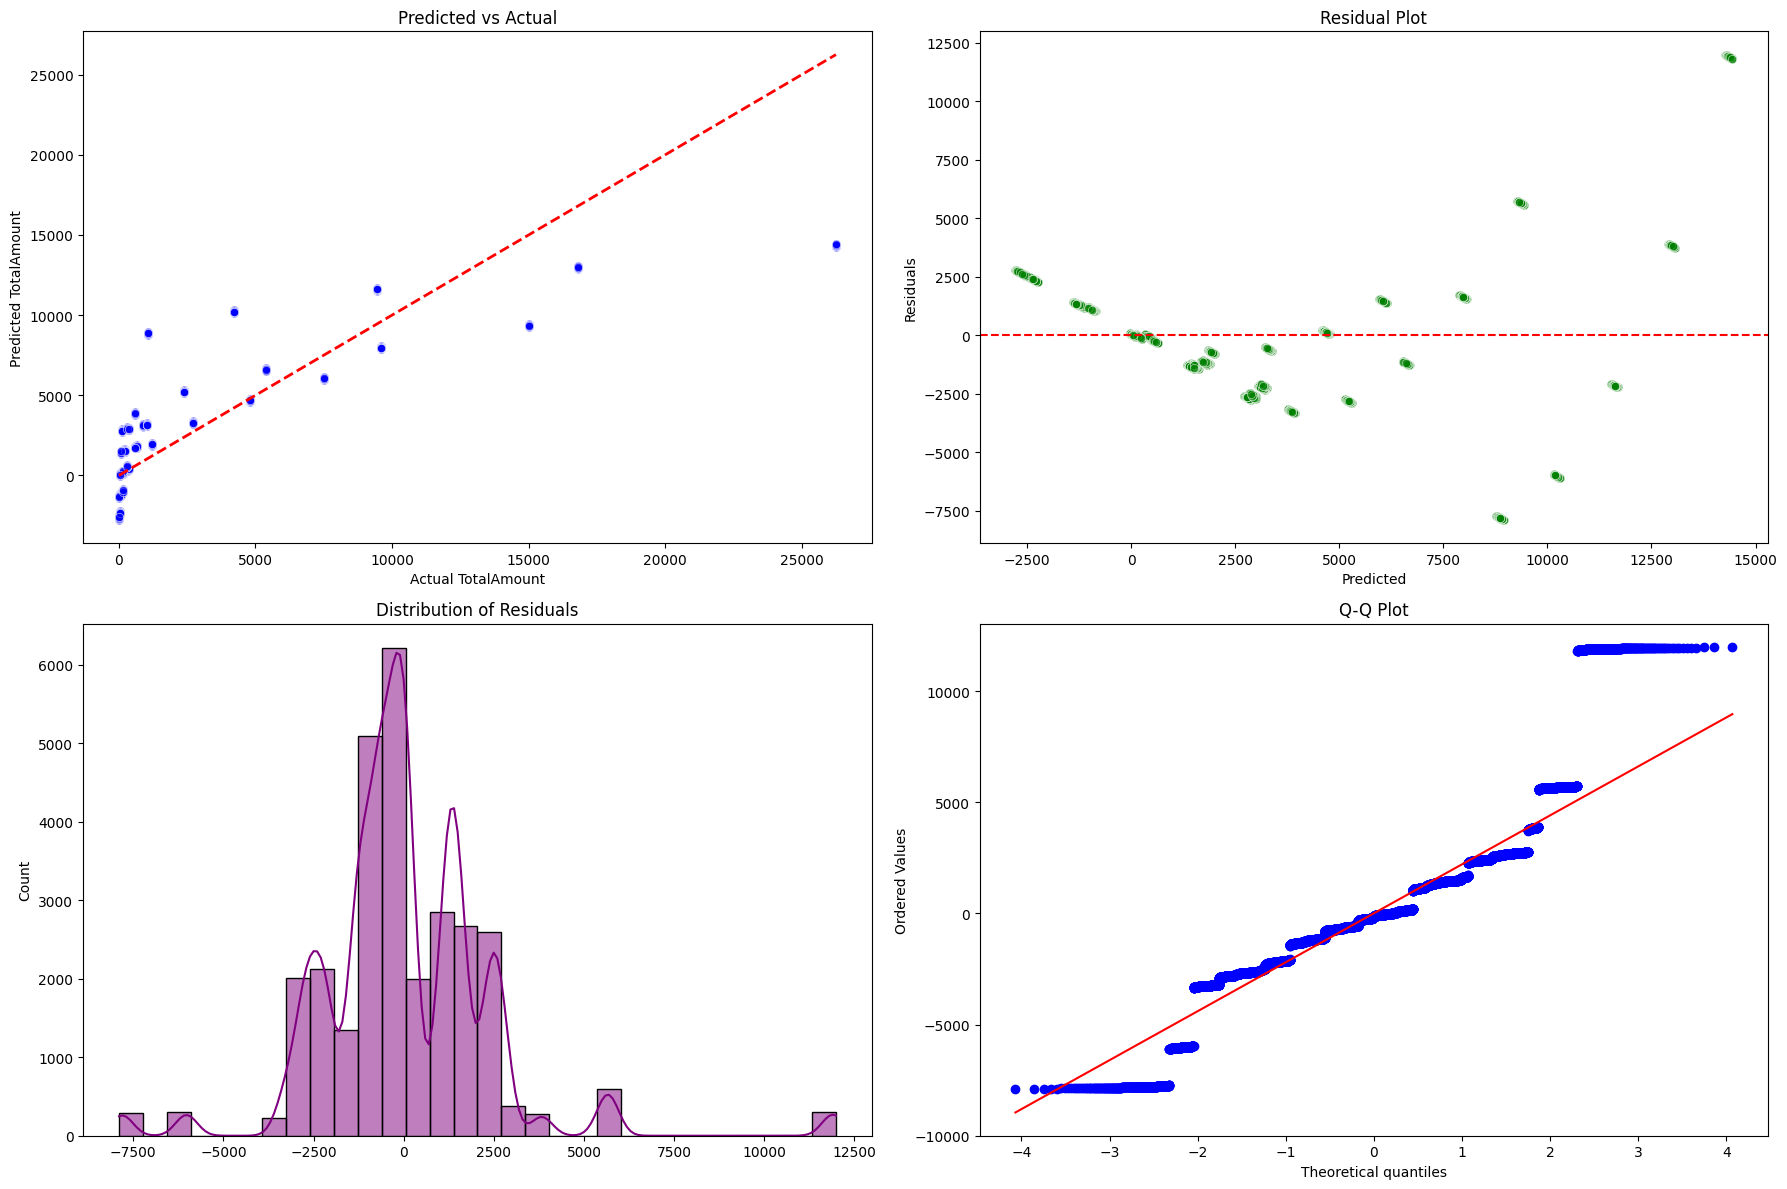

In [ ]:
# ====================== 10. TRỰC QUAN HÓA HIỆU SUẤT MÔ HÌNH ======================
residuals = y_test - y_pred

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual TotalAmount')
plt.ylabel('Predicted TotalAmount')
plt.title('Predicted vs Actual')

plt.subplot(2, 2, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.title('Distribution of Residuals')

plt.subplot(2, 2, 4)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()


In [ ]:
# ====================== 11. PHÂN TÍCH HỆ SỐ ======================
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_.round(4)
})

print("=== TOP 15 HỆ SỐ DƯƠNG LỚN NHẤT ===")
display(coef_table.sort_values(by='Coefficient', ascending=False).head(15))

print("=== TOP 15 HỆ SỐ ÂM LỚN NHẤT ===")
display(coef_table.sort_values(by='Coefficient', ascending=True).head(15))

print(f"Intercept: {lr.intercept_:.2f}")


=== TOP 15 HỆ SỐ DƯƠNG LỚN NHẤT ===


,Feature,Coefficient
12,category_Technology,11444.8946
10,category_Shoes,6443.3650
7,category_Clothing,3147.4443
0,quantity,1373.5191
8,category_Cosmetics,271.2719
13,category_Toys,231.2325
6,age_group_65-70,53.0011
3,age_group_35-44,45.8548
4,age_group_45-54,31.2508
11,category_Souvenir,18.2515


=== TOP 15 HỆ SỐ ÂM LỚN NHẤT ===


,Feature,Coefficient
9,category_Food & Beverage,-105.3335
16,shopping_mall_Emaar Square Mall,-89.3774
22,shopping_mall_Metropol AVM,-72.5843
21,shopping_mall_Metrocity,-61.1791
18,shopping_mall_Istinye Park,-54.9339
23,shopping_mall_Viaport Outlet,-51.2284
20,shopping_mall_Mall of Istanbul,-47.3949
24,shopping_mall_Zorlu Center,-46.2935
19,shopping_mall_Kanyon,-34.2692
15,payment_method_Debit Card,-31.4520


Intercept: -3923.62


In [ ]:
# ====================== 12. DỰ ĐOÁN CHO MẪU GIẢ ĐỊNH ======================
sample_input = pd.DataFrame([{
    'gender': 'Male',
    'age_group': '25-34',
    'category': 'Cosmetics',
    'quantity': 3,
    'payment_method': 'Credit Card',
    'shopping_mall': 'Kanyon'
}])

sample_encoded = pd.get_dummies(sample_input, drop_first=True)
sample_encoded = sample_encoded.reindex(columns=X_train.columns, fill_value=0)

sample_prediction = lr.predict(sample_encoded)[0]

print("=== DỰ ĐOÁN CHO MẪU GIẢ ĐỊNH ===")
display(sample_input)
print(f"Giá trị TotalAmount dự đoán: {sample_prediction:.2f}")


=== DỰ ĐOÁN CHO MẪU GIẢ ĐỊNH ===


,gender,age_group,category,quantity,payment_method,shopping_mall
0,Male,25-34,Cosmetics,3,Credit Card,Kanyon


Giá trị TotalAmount dự đoán: 196.94
